#Require Libraries

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from tensorflow.keras.preprocessing.image import load_img , img_to_array
from tensorflow.keras.models import Sequential , Model
from tensorflow.keras.layers import  Dense, Conv2D, MaxPooling2D,MaxPool2D ,UpSampling2D, Flatten, Input
from tensorflow.keras.optimizers import SGD, Adam, Adadelta, Adagrad
from keras import backend as K

#Load Data

In [2]:
!unzip /content/dataset-20260816T082506Z-1-001.zip

Archive:  /content/dataset-20260816T082506Z-1-001.zip
  inflating: dataset/49.jpg          
  inflating: dataset/73.jpg          
  inflating: dataset/90.jpg          
  inflating: dataset/82.jpg          
  inflating: dataset/53.jpg          
  inflating: dataset/26.jpg          
  inflating: dataset/89.jpg          
  inflating: dataset/55.jpg          
  inflating: dataset/47.jpg          
  inflating: dataset/74.jpg          
  inflating: dataset/21.jpg          
  inflating: dataset/40.jpg          
  inflating: dataset/12.jpg          
  inflating: dataset/79.jpg          
  inflating: dataset/24.jpg          
  inflating: dataset/81.jpg          
  inflating: dataset/29.jpg          
  inflating: dataset/6.jpg           
  inflating: dataset/44.jpg          
  inflating: dataset/68.jpg          
  inflating: dataset/9.jpg           
  inflating: dataset/18.jpg          
  inflating: dataset/76.jpg          
  inflating: dataset/39.jpg          
  inflating: dataset/58.jpg       

In [3]:
root_dir = "dataset/"
image_paths = os.listdir(root_dir)
print(len(image_paths))

100


In [4]:
images = []
for image_path in image_paths:
  img = load_img(root_dir +image_path ,target_size=(160,160) ,color_mode="grayscale")
  img = img_to_array(img)
  img = img / 255.
  images.append(img)

In [5]:
images = np.array(images)

In [6]:
type(images)

numpy.ndarray

#Plot Images

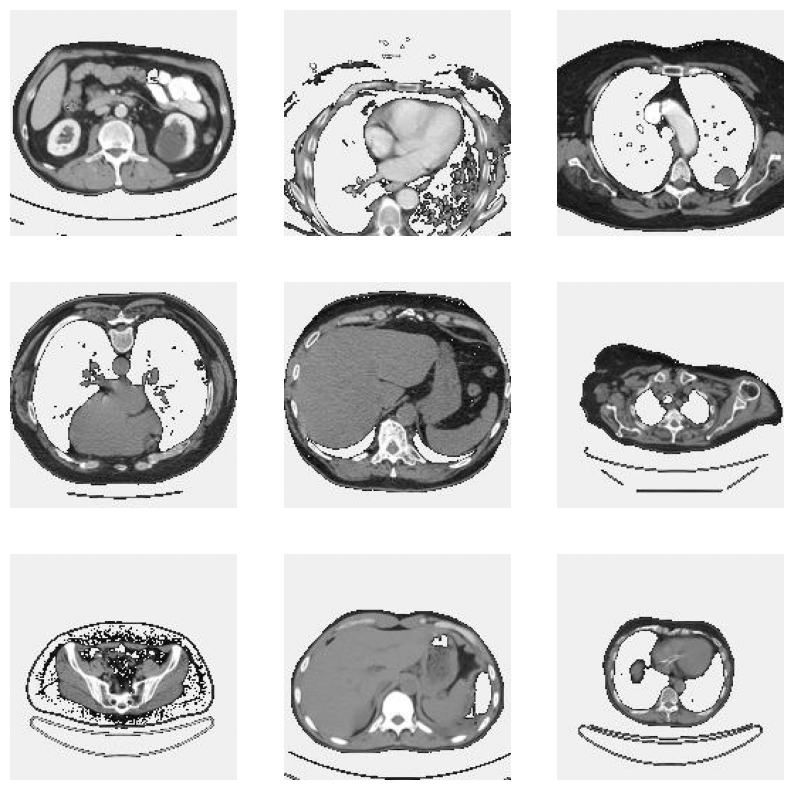

In [7]:
plt.figure(figsize=(10,10))
for i in range(9):
  plt.subplot(3 ,3 , i+1)
  plt.imshow(images[i].reshape(160 , 160) , cmap="gray")
  plt.axis("off")
plt.show()

#AutoEncoder

In [8]:
# Set the intensity of the noise to be added to the images
noise_factor = 0.2

# Initialize an empty list to store the processed noisy images
noise_images = []

# Add Gaussian noise to the image
for image in images:
  noisy = image + noise_factor * np.random.randn(*image.shape)
  noisy = np.clip(noisy, 0., 1.)
  noise_images.append(noisy)


In [9]:
noise_images = np.array(noise_images)

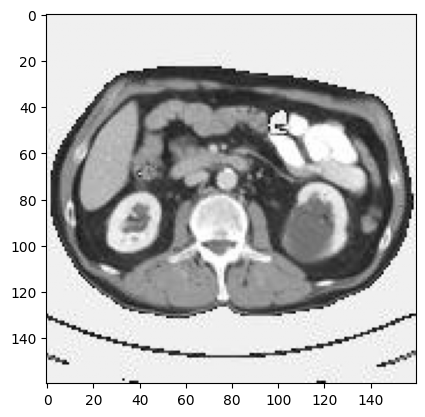

In [10]:
plt.imshow(images[0].reshape(160 , 160) , cmap="gray")
plt.show()

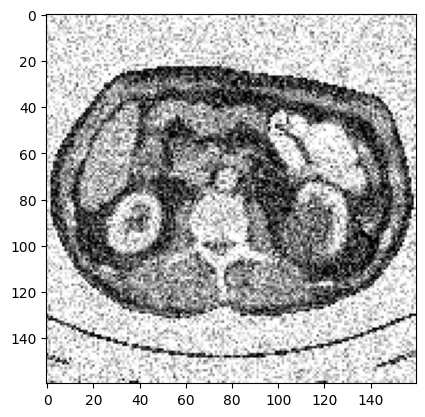

In [14]:
plt.imshow(noise_images[0].reshape(160 , 160), cmap="gray")
plt.show()

In [15]:
normal_train = images[:80]
normal_test = images[80:]
normal_train.shape , normal_test.shape

((80, 160, 160, 1), (20, 160, 160, 1))

In [16]:
noise_train = noise_images[:80]
noise_test = noise_images[80:]
noise_train.shape , noise_test.shape

((80, 160, 160, 1), (20, 160, 160, 1))

#Models

In [17]:
def autoencoder():
  input_img = Input(shape=(160,160,1) , name="image_input")

  #Encoder
  x=Conv2D(128, (3,3), activation='relu', padding='same', name="Conv1")(input_img)
  x=MaxPooling2D((2,2), padding='same', name="Pool1")(x)
  x=Conv2D(64, (3,3), activation='relu', padding='same', name="Conv2")(x)
  x=MaxPooling2D((2,2), padding='same', name="Pool2")(x)

  #Decoder
  x=Conv2D(64, (3,3), activation='relu', padding='same', name="Conv3")(x)
  x=UpSampling2D((2,2), name="Upsample1")(x)
  x=Conv2D(128, (3,3), activation='relu', padding='same', name="Conv4")(x)
  x=UpSampling2D((2,2), name="Upsample2")(x)
  x = Conv2D(1, (3,3), activation='sigmoid', padding='same', name='Conv5')(x)

  #Model
  autoencoder = Model(inputs=input_img, outputs=x)
  autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
  return autoencoder

In [18]:
model = autoencoder()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 160, 160, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv1 (Conv2D)                  │ (None, 160, 160, 128)  │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool1 (MaxPooling2D)            │ (None, 80, 80, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2 (Conv2D)                  │ (None, 80, 80, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool2 (MaxPooling2D)            │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv3 (Conv2D)                  │ (None, 40, 40, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Upsample1 (UpSampling2D)        │ (None, 80, 80, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv4 (Conv2D)                  │ (None, 80, 80, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Upsample2 (UpSampling2D)        │ (None, 160, 160, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv5 (Conv2D)                  │ (None, 160, 160, 1)    │         1,153 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 187,009 (730.50 KB)

 Trainable params: 187,009 (730.50 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint , ReduceLROnPlateau

#Checkpoint
checkpoint_callbacks = ModelCheckpoint(
    filepath = 'best_model.weights.h5',
    save_weights_only=True,
    monitor='val_loss',
    mode='min',
    save_best_only=True
)

#EarlyStopping
early_stopping_callbacks = EarlyStopping(
    monitor='val_loss',
    min_delta=0,
    patience=10,
    verbose=1,
    restore_best_weights=True
)

#ReduceLROnPlateau
reduce_lr_callbacks = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=0.001
)

In [20]:
model.fit(noise_train,
                 normal_train,
                 validation_data=(noise_test, normal_test),
                 epochs=500,
                 batch_size=8,
                 callbacks=[checkpoint_callbacks, early_stopping_callbacks, reduce_lr_callbacks])

Epoch 1/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 254ms/step - loss: 0.5706 - val_loss: 0.5251 - learning_rate: 0.0010
Epoch 2/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.4751 - val_loss: 0.4369 - learning_rate: 0.0010
Epoch 3/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.4279 - val_loss: 0.4245 - learning_rate: 0.0010
Epoch 4/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.4120 - val_loss: 0.4138 - learning_rate: 0.0010
Epoch 5/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.4027 - val_loss: 0.4069 - learning_rate: 0.0010
Epoch 6/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.3992 - val_loss: 0.4054 - learning_rate: 0.0010
Epoch 7/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.3956 - val_loss: 0.4040 - learning_rate: 0.0010
Epoch 8/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.3938 - val_loss: 0.4011 - learning_rate: 0.0010
Epoch 9/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.3916 - val_loss: 0.3994 - learning_rate: 0.0010
Epoch 10

In [21]:
predicted = model.predict(noise_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


In [22]:
# Calculate Mean Squared Error (MSE)
from sklearn.metrics import mean_squared_error

actual_values_flat = normal_test.flatten()
predicted_values_flat = predicted.flatten()

mse = mean_squared_error(actual_values_flat, predicted_values_flat)
print("Mean Squared Error (MSE):", mse)

Mean Squared Error (MSE): 0.007662247400730848


In [23]:
evaluation = model.evaluate(noise_test, normal_test)
print("Evaluation:", evaluation)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - loss: 0.3739
Evaluation: 0.37393325567245483


In [24]:
def plot_predictions(test, preds):
    plt.figure(figsize=(12, 10))

    # Noise test
    for i in range(16):
        plt.subplot(4, 8, i + 1)
        plt.imshow(test[i], cmap='gray')
        plt.axis('off')
        plt.title('Noised')

    # Predicted
    for i in range(16):
        plt.subplot(4, 8, i + 17)
        plt.imshow(preds[i], cmap='gray')
        plt.axis('off')
        plt.title('Predicted')

    plt.show()

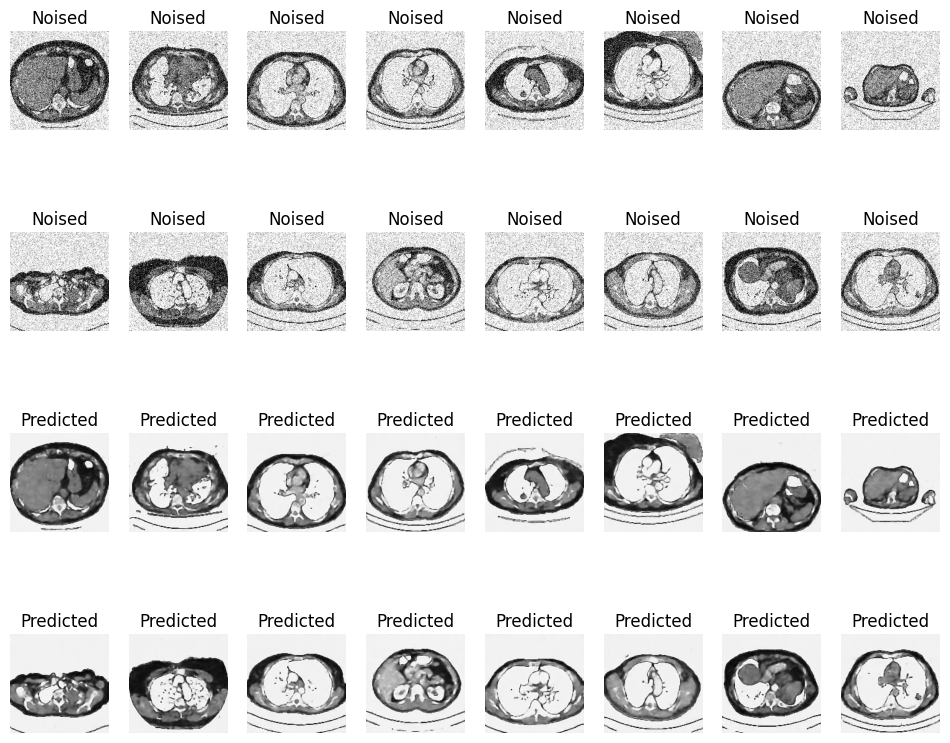

In [25]:
plot_predictions(noise_test, predicted)

In [26]:
import numpy as np
from skimage.metrics import peak_signal_noise_ratio

# Calculate PSNR for each pair of clean and denoised images and take the absolute value
psnr_values = [abs(peak_signal_noise_ratio(clean_img, denoised_img, data_range=denoised_img.max() - denoised_img.min())) for clean_img, denoised_img in zip(normal_test, predicted)]

# Calculate the average PSNR
average_psnr = np.mean(psnr_values)

# Print the average PSNR
print("Average PSNR:", average_psnr)


Average PSNR: 20.711244075378538
